Lab03 A1: Centroid and spread summary (showing shapes):
Class1 label: Child n: 6488 centroid shape: (13,)
Class2 label: Normal n: 6424 centroid shape: (13,)
Inter-centroid Euclidean distance: 76.09240901413861
Lab03 A2: MFCC1 mean=756.8045, variance=9637.8337


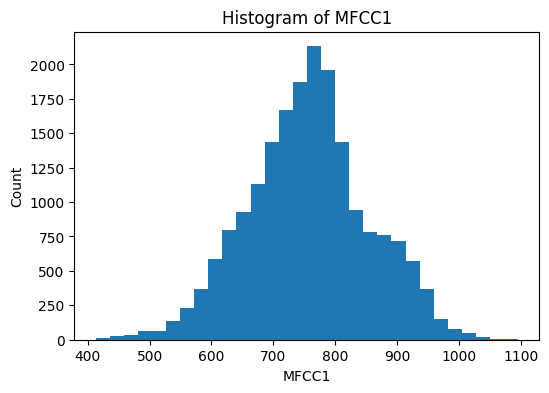

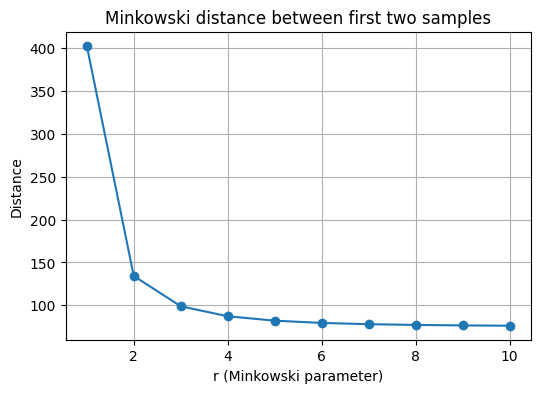

Lab03 A5-A7: k=3 test accuracy: 0.999225606608157
Confusion matrix:
 [[1945    2]
 [   1 1926]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1947
           1       1.00      1.00      1.00      1927

    accuracy                           1.00      3874
   macro avg       1.00      1.00      1.00      3874
weighted avg       1.00      1.00      1.00      3874



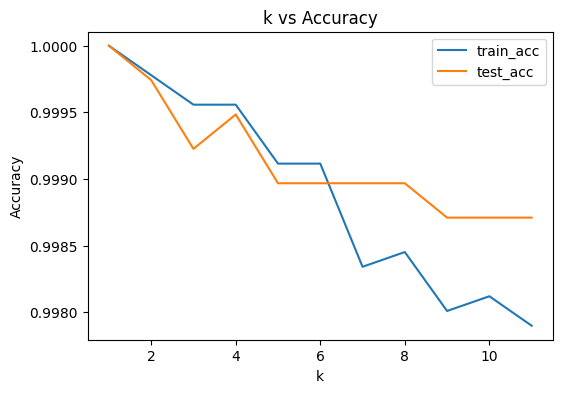

Lab03 A9: Train acc: 0.9995574242088958 Test acc: 0.999225606608157
Model appears to have reasonable fit based on accuracy comparison.


In [3]:
# Lab03_all_questions.py
# Lab03: A1 - A9 implementations
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Any
import math

# ---------- Utility functions ----------
def load_data(path: str = "/mnt/data/extracted_audio_features.csv"):
    df = pd.read_csv('/Users/dhrithijuvva/Desktop/Women_ML/extracted_audio_features.csv')
    feature_cols = [c for c in df.columns if c.startswith("MFCC")]
    X = df[feature_cols].values
    y = df["Label"].values
    return df, X, y, feature_cols

# ---------- Lab03 A1 ----------
def class_centroids_and_spreads(X: np.ndarray, y: np.ndarray, classes: Tuple[Any,Any]=None):
    """
    Calculate centroids and standard deviations for two classes. If classes None, pick first two unique labels.
    Returns dict with centroid and spread per class and inter-centroid distance.
    """
    unique = np.unique(y)
    if classes is None:
        if len(unique) < 2:
            raise ValueError("Need at least two classes in y")
        classes = (unique[0], unique[1])
    c1_idx = np.where(y == classes[0])[0]
    c2_idx = np.where(y == classes[1])[0]
    centroid1 = X[c1_idx].mean(axis=0)
    centroid2 = X[c2_idx].mean(axis=0)
    spread1 = X[c1_idx].std(axis=0)
    spread2 = X[c2_idx].std(axis=0)
    inter_dist = np.linalg.norm(centroid1 - centroid2)
    return {
        "class_1": {"label": classes[0], "centroid": centroid1, "spread": spread1, "n": len(c1_idx)},
        "class_2": {"label": classes[1], "centroid": centroid2, "spread": spread2, "n": len(c2_idx)},
        "inter_centroid_distance": inter_dist
    }

# ---------- Lab03 A2 ----------
def plot_feature_histogram(df: pd.DataFrame, feature: str, bins: int = 30):
    """
    Returns mean and variance and draws histogram (main will show).
    """
    values = df[feature].dropna().values
    mean = values.mean()
    var = values.var(ddof=0)
    plt.figure(figsize=(6,4))
    plt.hist(values, bins=bins)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    return {"mean": mean, "variance": var}

# ---------- Lab03 A3 ----------
def minkowski_distances(vec1: np.ndarray, vec2: np.ndarray, rmin: int = 1, rmax: int = 10):
    """
    Calculate Minkowski distance between two 1-D vectors for r in [rmin, rmax].
    Returns (r_list, dist_list)
    """
    r_list = list(range(rmin, rmax+1))
    dists = []
    for r in r_list:
        d = np.sum(np.abs(vec1 - vec2) ** r) ** (1.0/r)
        dists.append(d)
    return r_list, dists

# ---------- Lab03 A4-A7 ----------
def get_train_test_two_classes(X: np.ndarray, y: np.ndarray, class_pair=None, test_size: float = 0.3, random_state: int = 42):
    """
    Select only two classes (first two if not provided), split into train/test.
    """
    unique = np.unique(y)
    if class_pair is None:
        if len(unique) < 2:
            raise ValueError("Need at least two classes")
        class_pair = (unique[0], unique[1])
    mask = np.isin(y, class_pair)
    X2 = X[mask]
    y2 = y[mask]
    # Re-encode labels to 0/1 for convenience
    labels_unique = np.unique(y2)
    mapping = {labels_unique[0]:0, labels_unique[1]:1}
    y2_enc = np.vectorize(mapping.get)(y2)
    Xtr, Xte, ytr, yte = train_test_split(X2, y2_enc, test_size=test_size, random_state=random_state, stratify=y2_enc)
    return Xtr, Xte, ytr, yte, mapping

def train_knn(X_train, y_train, k=3, metric='minkowski'):
    neigh = KNeighborsClassifier(n_neighbors=k, metric=metric)
    neigh.fit(X_train, y_train)
    return neigh

def evaluate_classifier(model, X, y):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm, "y_pred": y_pred}

# ---------- Lab03 A8: vary k ----------
def vary_k_plot(X_train, y_train, X_test, y_test, kmin=1, kmax=11):
    ks = list(range(kmin, kmax+1, 2)) if (kmax-kmin)>10 else list(range(kmin, kmax+1))
    train_acc = []
    test_acc = []
    for k in ks:
        model = train_knn(X_train, y_train, k=k)
        train_acc.append(model.score(X_train, y_train))
        test_acc.append(model.score(X_test, y_test))
    plt.figure(figsize=(6,4))
    plt.plot(ks, train_acc, label="train_acc")
    plt.plot(ks, test_acc, label="test_acc")
    plt.xlabel("k")
    plt.ylabel("Accuracy")
    plt.title("k vs Accuracy")
    plt.legend()
    return {"ks": ks, "train_acc": train_acc, "test_acc": test_acc}

# ---------- Lab03 Main ----------
if __name__ == "__main__":
    df, X, y, feature_cols = load_data()
    # A1
    a1 = class_centroids_and_spreads(X, y)
    print("Lab03 A1: Centroid and spread summary (showing shapes):")
    print("Class1 label:", a1["class_1"]["label"], "n:", a1["class_1"]["n"], "centroid shape:", a1["class_1"]["centroid"].shape)
    print("Class2 label:", a1["class_2"]["label"], "n:", a1["class_2"]["n"], "centroid shape:", a1["class_2"]["centroid"].shape)
    print("Inter-centroid Euclidean distance:", a1["inter_centroid_distance"])

    # A2 - histogram for MFCC1
    a2 = plot_feature_histogram(df, feature_cols[0], bins=30)
    print(f"Lab03 A2: {feature_cols[0]} mean={a2['mean']:.4f}, variance={a2['variance']:.4f}")
    plt.show()

    # A3 - minkowski distance between first two rows
    v1 = X[0]
    v2 = X[1]
    r_list, dists = minkowski_distances(v1, v2, 1, 10)
    plt.figure(figsize=(6,4))
    plt.plot(r_list, dists, marker='o')
    plt.xlabel("r (Minkowski parameter)")
    plt.ylabel("Distance")
    plt.title("Minkowski distance between first two samples")
    plt.grid(True)
    plt.show()

    # A4 - A7 prepare two-class split and train kNN k=3
    Xtr, Xte, ytr, yte, mapping = get_train_test_two_classes(X, y)
    model_k3 = train_knn(Xtr, ytr, k=3)
    test_eval = evaluate_classifier(model_k3, Xte, yte)
    print("Lab03 A5-A7: k=3 test accuracy:", test_eval["accuracy"])
    print("Confusion matrix:\n", test_eval["confusion_matrix"])
    print("Classification report:\n", classification_report(yte, test_eval["y_pred"], zero_division=0))

    # A8 vary k and plot
    varres = vary_k_plot(Xtr, ytr, Xte, yte, kmin=1, kmax=11)
    plt.show()

    # A9 compute confusion & metrics for training set as well
    train_eval = evaluate_classifier(model_k3, Xtr, ytr)
    print("Lab03 A9: Train acc:", train_eval["accuracy"], "Test acc:", test_eval["accuracy"])
    # Inference simple guidance:
    if train_eval["accuracy"] - test_eval["accuracy"] > 0.1:
        print("Model may be overfitting (train >> test).")
    elif test_eval["accuracy"] < 0.6:
        print("Model may be underfitting (both low).")
    else:
        print("Model appears to have reasonable fit based on accuracy comparison.")
